# 296M Loss Curves

Interactive notebook for previewing and plotting validation-loss CSV files under `outputs/loss_csv/296m`.


In [12]:
from pathlib import Path
import csv
import pandas as pd
import matplotlib.pyplot as plt

INPUT_DIR = Path('/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/outputs/loss_csv/296m')
OUTPUT_DIR = INPUT_DIR / 'plots'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CLIP_TO_COMMON_MAX_STEP = True
USE_LOG_X = False
USE_LOG_Y = True

csv_paths = sorted(INPUT_DIR.glob('*.csv'))
csv_paths

[PosixPath('/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/outputs/loss_csv/296m/project_20260402_c4b7f427_val_loss_20260502_105113.csv'),
 PosixPath('/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/outputs/loss_csv/296m/project_20260402_c4b7f427_val_loss_20260502_105232.csv'),
 PosixPath('/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/outputs/loss_csv/296m/project_20260402_c4b7f427_val_loss_20260502_105350.csv')]

In [13]:
def load_loss_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [str(c).replace('\ufeff', '').strip() for c in df.columns]
    if len(df.columns) < 2:
        raise ValueError(f'Expected at least 2 columns in {path}')
    x_col, y_col = df.columns[:2]
    out = df[[x_col, y_col]].copy()
    out.columns = ['x', 'loss']
    out['x'] = pd.to_numeric(out['x'], errors='coerce')
    out['loss'] = pd.to_numeric(out['loss'], errors='coerce')
    out = out.dropna().reset_index(drop=True)
    out['source'] = path.name
    out.attrs['x_name'] = x_col
    out.attrs['y_name'] = y_col
    return out

dfs = [load_loss_csv(path) for path in csv_paths]
common_max_step = min(df['x'].max() for df in dfs)
print('common_max_step =', common_max_step)
[(df.attrs['x_name'], df.attrs['y_name'], len(df), df['source'].iloc[0]) for df in dfs]

common_max_step = 11110


[('iter',
  'project_20260402_c4b7f427/run_20260430_286be9fc/cn',
  67,
  'project_20260402_c4b7f427_val_loss_20260502_105113.csv'),
 ('Step',
  'project_20260402_c4b7f427/run_20260417_5471a202/cn',
  111,
  'project_20260402_c4b7f427_val_loss_20260502_105232.csv'),
 ('Step',
  'project_20260402_c4b7f427/run_20260417_f5116792/cn',
  304,
  'project_20260402_c4b7f427_val_loss_20260502_105350.csv')]

In [14]:
for df in dfs:
    display(df.head())

,x,loss,source
0,0,18.944267,project_20260402_c4b7f427_val_loss_20260502_10...
1,1000,4.944901,project_20260402_c4b7f427_val_loss_20260502_10...
2,2000,3.796495,project_20260402_c4b7f427_val_loss_20260502_10...
3,3000,3.434522,project_20260402_c4b7f427_val_loss_20260502_10...
4,4000,3.276623,project_20260402_c4b7f427_val_loss_20260502_10...


,x,loss,source
0,0,11.101524,project_20260402_c4b7f427_val_loss_20260502_10...
1,101,5.001888,project_20260402_c4b7f427_val_loss_20260502_10...
2,202,3.896620,project_20260402_c4b7f427_val_loss_20260502_10...
3,303,3.531869,project_20260402_c4b7f427_val_loss_20260502_10...
4,404,3.376185,project_20260402_c4b7f427_val_loss_20260502_10...


,x,loss,source
0,0,11.101849,project_20260402_c4b7f427_val_loss_20260502_10...
1,101,4.992132,project_20260402_c4b7f427_val_loss_20260502_10...
2,202,3.889334,project_20260402_c4b7f427_val_loss_20260502_10...
3,303,3.534007,project_20260402_c4b7f427_val_loss_20260502_10...
4,404,3.372214,project_20260402_c4b7f427_val_loss_20260502_10...


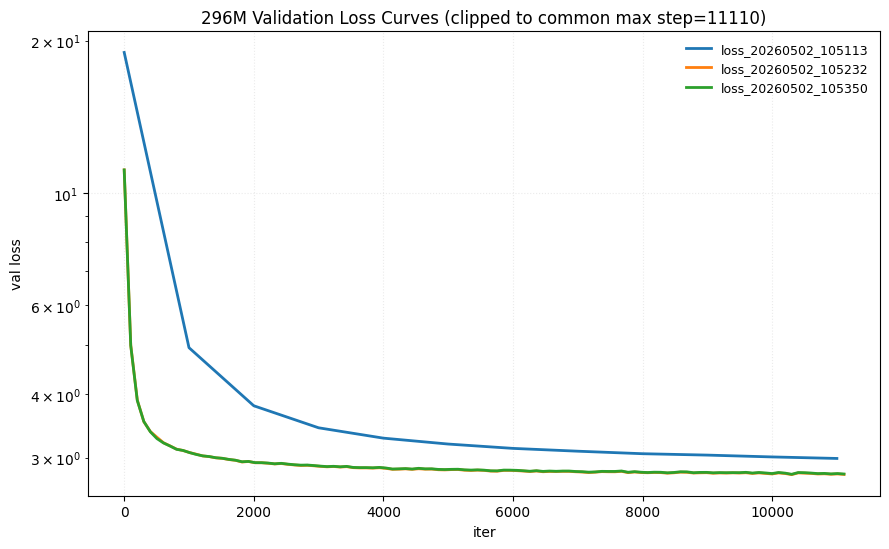

In [15]:
plt.figure(figsize=(9, 5.6))
for df in dfs:
    if CLIP_TO_COMMON_MAX_STEP:
        df = df[df['x'] <= common_max_step].copy()
    label = df['source'].iloc[0].replace('.csv', '')[-20:]
    plt.plot(df['x'], df['loss'], linewidth=2.0, label=label)
plt.xlabel(dfs[0].attrs['x_name'])
plt.ylabel('val loss')
plt.title(f'296M Validation Loss Curves (clipped to common max step={int(common_max_step)})')
if USE_LOG_X:
    plt.xscale('log')
if USE_LOG_Y:
    plt.yscale('log')
plt.grid(alpha=0.25, linestyle=':')
plt.legend(frameon=True, fontsize=9, facecolor='white', edgecolor='#cfcfcf')
plt.tight_layout()
plt.show()

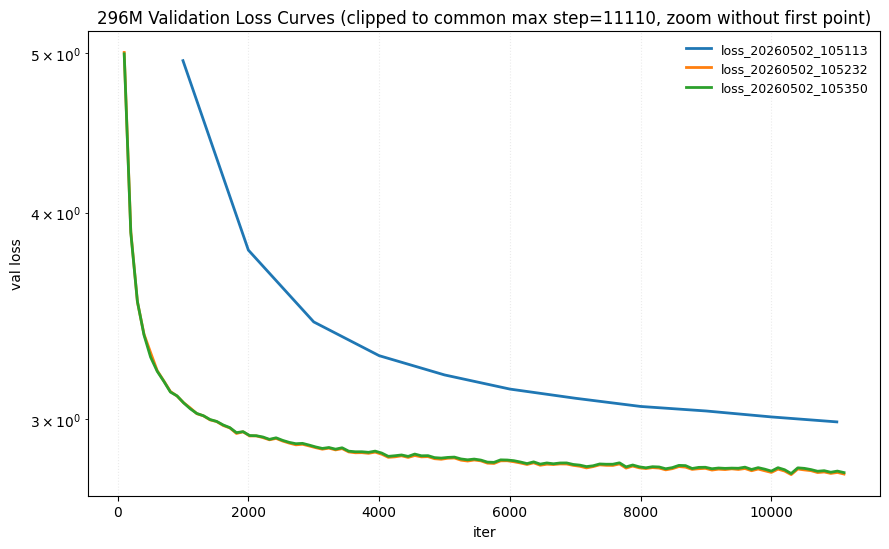

In [16]:
plt.figure(figsize=(9, 5.6))
for df in dfs:
    if CLIP_TO_COMMON_MAX_STEP:
        df = df[df['x'] <= common_max_step].copy()
    label = df['source'].iloc[0].replace('.csv', '')[-20:]
    df_zoom = df.iloc[1:].copy() if len(df) > 1 else df.copy()
    plt.plot(df_zoom['x'], df_zoom['loss'], linewidth=2.0, label=label)
plt.xlabel(dfs[0].attrs['x_name'])
plt.ylabel('val loss')
plt.title(f'296M Validation Loss Curves (clipped to common max step={int(common_max_step)}, zoom without first point)')
if USE_LOG_X:
    plt.xscale('log')
if USE_LOG_Y:
    plt.yscale('log')
plt.grid(alpha=0.25, linestyle=':')
plt.legend(frameon=True, fontsize=9, facecolor='white', edgecolor='#cfcfcf')
plt.tight_layout()
plt.show()

In [17]:
suffix_parts = []
if CLIP_TO_COMMON_MAX_STEP:
    suffix_parts.append('clipped')
if USE_LOG_X:
    suffix_parts.append('logx')
if USE_LOG_Y:
    suffix_parts.append('logy')
suffix = ('_' + '_'.join(suffix_parts)) if suffix_parts else ''
full_path = OUTPUT_DIR / f'loss_curves_296m_full_from_notebook{suffix}.png'
zoom_path = OUTPUT_DIR / f'loss_curves_296m_zoom_from_notebook{suffix}.png'

fig = plt.figure(figsize=(9, 5.6))
for df in dfs:
    if CLIP_TO_COMMON_MAX_STEP:
        df = df[df['x'] <= common_max_step].copy()
    label = df['source'].iloc[0].replace('.csv', '')[-20:]
    plt.plot(df['x'], df['loss'], linewidth=2.0, label=label)
plt.xlabel(dfs[0].attrs['x_name'])
plt.ylabel('val loss')
plt.title(f'296M Validation Loss Curves (clipped to common max step={int(common_max_step)})')
if USE_LOG_X:
    plt.xscale('log')
if USE_LOG_Y:
    plt.yscale('log')
plt.grid(alpha=0.25, linestyle=':')
plt.legend(frameon=True, fontsize=9, facecolor='white', edgecolor='#cfcfcf')
plt.tight_layout()
plt.savefig(full_path, dpi=220)
plt.close(fig)

fig = plt.figure(figsize=(9, 5.6))
for df in dfs:
    if CLIP_TO_COMMON_MAX_STEP:
        df = df[df['x'] <= common_max_step].copy()
    label = df['source'].iloc[0].replace('.csv', '')[-20:]
    df_zoom = df.iloc[1:].copy() if len(df) > 1 else df.copy()
    plt.plot(df_zoom['x'], df_zoom['loss'], linewidth=2.0, label=label)
plt.xlabel(dfs[0].attrs['x_name'])
plt.ylabel('val loss')
plt.title(f'296M Validation Loss Curves (clipped to common max step={int(common_max_step)}, zoom without first point)')
if USE_LOG_X:
    plt.xscale('log')
if USE_LOG_Y:
    plt.yscale('log')
plt.grid(alpha=0.25, linestyle=':')
plt.legend(frameon=True, fontsize=9, facecolor='white', edgecolor='#cfcfcf')
plt.tight_layout()
plt.savefig(zoom_path, dpi=220)
plt.close(fig)

print(full_path)
print(zoom_path)

/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/outputs/loss_csv/296m/plots/loss_curves_296m_full_from_notebook_clipped_logy.png
/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/outputs/loss_csv/296m/plots/loss_curves_296m_zoom_from_notebook_clipped_logy.png
